# exp05b - AR-LRX Rossmann: verifikasi, ablasi gerbang, dan uji skala asli

## Mengapa eksperimen ini ada

exp05a sudah menunjukkan hasil yang kuat: `AR-LRX [struct_linear]` menang empat arah
(vs naif, vs XGBoost polos, vs kerangka lama, vs tahap pertamanya sendiri) pada
**ketiga** varian yang sah. Namun ada tiga celah yang **pasti** ditanyakan reviewer
Q1/Q2, dan ketiganya ditutup di sini tanpa mengubah satu pun keputusan pemodelan.

| Celah pada exp05a | Yang ditutup exp05b |
|---|---|
| **C1.** Tabel utama melaporkan RMSE **skala asli**, tetapi uji Diebold-Mariano dihitung pada **skala log**. Reviewer berhak menuntut uji signifikansi pada skala yang dilaporkan. | Uji DM dijalankan pada **kedua skala**, disandingkan. |
| **C2.** Ablasi belum memisahkan sumbangan gerbang **pada tahap pertama yang baik**. Baris `+ gerbang saja` memakai `S1 = linear`; tidak ada sel `S1 struktural tanpa gerbang`. | Ablasi lengkap 3x2 (tiga `S1` x gerbang mati/hidup), dihitung **tanpa melatih ulang apa pun**. |
| **C3.** Tidak ada bukti bahwa `w` pilihan validation mendekati `w` terbaik di test. Tanpa itu, gerbang bisa dituduh sekadar parameter tambahan yang beruntung. | Kurva sensitivitas RMSE test terhadap `w` penuh, dengan penanda `w` pilihan validation. **Post-hoc, bukan pemilihan.** |

## Yang TIDAK berubah

Protokol, seed, split, grid, dan definisi model identik dengan exp05a. Bagian 2
memverifikasi bahwa seluruh angka exp05a **tereproduksi persis**. Bila verifikasi itu
lulus, exp05b menggantikan exp05a sebagai sumber tabel naskah; bila gagal, ada
masalah lingkungan yang harus diselesaikan lebih dulu.

## Prasyarat

Ganti `src/experiments/arlrx.py` dengan versi terbaru (yang menyimpan
`_test_correction`), lalu **Restart Kernel**. Penambahan itu murni penyimpanan
prediksi; tidak ada satu pun angka yang berubah karenanya.

In [1]:
import sys, os, json, warnings
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments import protocol as P
from src.experiments import arlrx as A

P.set_global_seed()
EXPERIMENT = "exp05b_rossmann_arlrx_audit"
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
print("Lingkungan:", P.environment_stamp())

# Prasyarat: arlrx.py versi baru
import inspect
assert "_test_correction" in inspect.getsource(A.run_arlrx), (
    "arlrx.py masih versi lama. Ganti berkasnya, lalu Restart Kernel.")
print("arlrx.py: versi dengan penyimpanan koreksi  OK")

Lingkungan: {'python': '3.10.11', 'platform': 'Windows-10-10.0.22621-SP0', 'numpy': '2.2.6', 'pandas': '2.3.3', 'seed': '42', 'sklearn': '1.7.2', 'xgboost': '3.2.0', 'statsmodels': '0.14.6'}
arlrx.py: versi dengan penyimpanan koreksi  OK


## 1. Data dan model - identik dengan exp05a

Sembilan model per varian, urutan dan argumen sama persis. Satu-satunya perbedaan:
seluruh prediksi test disimpan ke cakram, sehingga setiap analisis lanjutan
(residual per toko, dekomposisi galat, kurva gerbang, uji apa pun) dapat dilakukan
di kemudian hari **tanpa melatih ulang**.

In [2]:
frame = P.build_rossmann_frame("../data/raw/rossmann/train.csv",
                               "../data/raw/rossmann/store.csv")
VARIANTS = ["V1_customers_dropped", "V2_customers_lagged", "V3_sales_lagged"]

QUICK_RUN = False   # biarkan False: exp05b harus sebanding dengan exp05a

if QUICK_RUN:
    keep = np.sort(frame["Store"].unique())[:80]
    frame = frame[frame["Store"].isin(keep)].reset_index(drop=True)
    XGB_GRID = {"n_estimators": [300], "max_depth": [6], "learning_rate": [0.1],
                "subsample": [0.8], "colsample_bytree": [0.8], "max_bin": [256]}
else:
    XGB_GRID = A.GRID_XGB_ARLRX

datasets = {v: P.build_rossmann_dataset(frame, v, target="log1p") for v in VARIANTS}
print("Bentuk kerangka:", frame.shape, "| toko:", frame["Store"].nunique())

Bentuk kerangka: (838760, 23) | toko: 1115


In [3]:
rows = []
for variant in VARIANTS:
    d = datasets[variant]
    rows.append(P.rossmann_seasonal_naive(d, inverse_transform=np.expm1))
    for kind in A.STAGE1_KINDS:
        rows.append(A.run_stage1_only(f"S1 [{kind}]", d, kind,
                                      inverse_transform=np.expm1))
        rows.append(A.run_arlrx(f"AR-LRX [{kind}]", d, kind, XGB_GRID,
                                inverse_transform=np.expm1))
        print(f"  {variant:24s} S1={kind:14s} selesai", flush=True)
    rows.append(P.run_model("XGBoost", P.fp_xgboost, d, XGB_GRID,
                            inverse_transform=np.expm1))
    rows.append(P.run_model("LR-XGB (residual, tanpa gerbang)", P.fp_lr_xgb_residual,
                            d, XGB_GRID, inverse_transform=np.expm1))
    print(f"  {variant:24s} pembanding selesai", flush=True)

results = P.save_results(rows, EXPERIMENT)
by_key = {(r["feature_set"], r["model"]): r for r in rows}
print(f"\n{len(results)} baris ditulis ke ../results/{EXPERIMENT}.csv")

  V1_customers_dropped     S1=linear         selesai
  V1_customers_dropped     S1=structural     selesai
  V1_customers_dropped     S1=struct_linear  selesai
  V1_customers_dropped     pembanding selesai
  V2_customers_lagged      S1=linear         selesai
  V2_customers_lagged      S1=structural     selesai
  V2_customers_lagged      S1=struct_linear  selesai
  V2_customers_lagged      pembanding selesai
  V3_sales_lagged          S1=linear         selesai
  V3_sales_lagged          S1=structural     selesai
  V3_sales_lagged          S1=struct_linear  selesai
  V3_sales_lagged          pembanding selesai

27 baris ditulis ke ../results/exp05b_rossmann_arlrx_audit.csv


In [4]:
# Simpan seluruh prediksi test agar analisis lanjutan tidak perlu melatih ulang.
store = {}
for (variant, model), r in by_key.items():
    tag = f"{variant}|{model}"
    store[f"{tag}|test_pred"] = np.asarray(r["_test_pred"], dtype=np.float32)
    for extra_key in ("_stage1_test_raw", "_test_correction"):
        if extra_key in r:
            store[f"{tag}|{extra_key[1:]}"] = np.asarray(r[extra_key], dtype=np.float32)
for v in VARIANTS:
    store[f"{v}|y_test"] = np.asarray(datasets[v].y_test, dtype=np.float32)

path = f"../results/{EXPERIMENT}_predictions.npz"
np.savez_compressed(path, **store)
print(f"{len(store)} larik disimpan ke {path} "
      f"({os.path.getsize(path)/1e6:.1f} MB)")

48 larik disimpan ke ../results/exp05b_rossmann_arlrx_audit_predictions.npz (19.2 MB)


## 2. Verifikasi reproduksi terhadap exp05a

Angka exp05b harus identik dengan exp05a sampai batas presisi mesin. Bila ada satu
saja baris yang meleset, seluruh analisis di bawah tidak boleh dipakai.

In [5]:
ref_path = "../results/exp05a_rossmann_arlrx.csv"
if os.path.exists(ref_path):
    ref = pd.read_csv(ref_path)
    key = ["feature_set", "model"]
    cmp_cols = ["test_RMSE", "orig_RMSE", "orig_MAE", "orig_R2", "gate_w"]
    merged = (results[key + cmp_cols]
              .merge(ref[key + cmp_cols], on=key, suffixes=("_b", "_a")))
    bad = []
    for c in cmp_cols:
        diff = (merged[f"{c}_b"] - merged[f"{c}_a"]).abs()
        tol = 1e-9 if c == "gate_w" else 1e-6
        n_bad = int((diff > tol).sum())
        print(f"  {c:12s}: maks selisih = {diff.max():.3e}   melebihi toleransi: {n_bad}")
        if n_bad:
            bad.append(c)
    print("\nREPRODUKSI PERSIS:", not bad)
    if bad:
        print("  Kolom bermasalah:", bad)
        display(merged[key + [f"{c}_a" for c in bad] + [f"{c}_b" for c in bad]])
else:
    print(f"{ref_path} tidak ditemukan - lewati verifikasi.")

  test_RMSE   : maks selisih = 8.327e-17   melebihi toleransi: 0
  orig_RMSE   : maks selisih = 4.547e-13   melebihi toleransi: 0
  orig_MAE    : maks selisih = 2.274e-13   melebihi toleransi: 0
  orig_R2     : maks selisih = 2.776e-17   melebihi toleransi: 0
  gate_w      : maks selisih = 0.000e+00   melebihi toleransi: 0

REPRODUKSI PERSIS: True


## 3. Uji Diebold-Mariano pada DUA skala

Naskah melaporkan RMSE skala asli, maka signifikansi juga harus diuji di sana.
Skala log tetap dilaporkan agar dapat dibandingkan dengan exp05a dan dengan
literatur yang bekerja pada target tertransformasi.

Nilai DM negatif berarti AR-LRX lebih akurat. Kolom `sepakat` menandai apakah kedua
skala memberi kesimpulan yang sama - inilah yang sebenarnya ingin dilihat reviewer.

In [6]:
dm_rows = []
for variant in VARIANTS:
    d = datasets[variant]
    y_log = d.y_test
    y_orig = np.expm1(y_log)
    for kind in A.STAGE1_KINDS:
        prop = by_key[(variant, f"AR-LRX [{kind}]")]
        refs = [("XGBoost polos", by_key[(variant, "XGBoost")]),
                ("Naif per toko", by_key[(variant, "SeasonalNaive(store x dow x promo median)")]),
                ("Kerangka lama", by_key[(variant, "LR-XGB (residual, tanpa gerbang)")]),
                (f"S1 [{kind}] sendirian", by_key[(variant, f"S1 [{kind}]")])]
        for label, ref in refs:
            t_log = P.diebold_mariano(y_log, prop["_test_pred"], ref["_test_pred"])
            t_org = P.diebold_mariano(y_orig, np.expm1(prop["_test_pred"]),
                                      np.expm1(ref["_test_pred"]))
            win_log = t_log["DM"] < 0
            win_org = t_org["DM"] < 0
            sig_log = t_log["p_value"] < 0.05
            sig_org = t_org["p_value"] < 0.05
            dm_rows.append({
                "varian": variant, "S1": kind, "pembanding": label,
                "DM (log)": round(t_log["DM"], 3), "p (log)": t_log["p_value"],
                "DM (asli)": round(t_org["DM"], 3), "p (asli)": t_org["p_value"],
                "menang log": bool(win_log) and bool(sig_log),
                "menang asli": bool(win_org) and bool(sig_org),
                "sepakat": (bool(win_log) == bool(win_org)),
            })

dm2 = pd.DataFrame(dm_rows)
dm2.to_csv(f"../results/{EXPERIMENT}_dm_two_scales.csv", index=False)
display(dm2.to_string(index=False))

print(f"\nKedua skala sepakat arahnya : {int(dm2.sepakat.sum())} dari {len(dm2)}")
print(f"Menang signifikan (log)     : {int(dm2['menang log'].sum())} dari {len(dm2)}")
print(f"Menang signifikan (asli)    : {int(dm2['menang asli'].sum())} dari {len(dm2)}")
print("\nKonfigurasi utama saja (S1 = struct_linear):")
display(dm2[dm2.S1 == "struct_linear"].to_string(index=False))

'              varian            S1                   pembanding  DM (log)      p (log)  DM (asli)     p (asli)  menang log  menang asli  sepakat\nV1_customers_dropped        linear                XGBoost polos     2.742 6.111310e-03      4.190 2.788962e-05       False        False     True\nV1_customers_dropped        linear                Naif per toko    64.979 0.000000e+00     53.773 0.000000e+00       False        False     True\nV1_customers_dropped        linear                Kerangka lama       NaN          NaN        NaN          NaN       False        False     True\nV1_customers_dropped        linear        S1 [linear] sendirian  -147.230 0.000000e+00    -99.270 0.000000e+00        True         True     True\nV1_customers_dropped    structural                XGBoost polos   -81.135 0.000000e+00    -64.773 0.000000e+00        True         True     True\nV1_customers_dropped    structural                Naif per toko   -36.515 0.000000e+00    -28.831 0.000000e+00        True 


Kedua skala sepakat arahnya : 36 dari 36
Menang signifikan (log)     : 29 dari 36
Menang signifikan (asli)    : 29 dari 36

Konfigurasi utama saja (S1 = struct_linear):


'              varian            S1                   pembanding  DM (log)      p (log)  DM (asli)  p (asli)  menang log  menang asli  sepakat\nV1_customers_dropped struct_linear                XGBoost polos   -81.416 0.000000e+00    -64.953  0.000000        True         True     True\nV1_customers_dropped struct_linear                Naif per toko   -36.874 0.000000e+00    -29.746  0.000000        True         True     True\nV1_customers_dropped struct_linear                Kerangka lama   -81.562 0.000000e+00    -65.007  0.000000        True         True     True\nV1_customers_dropped struct_linear S1 [struct_linear] sendirian   -20.269 0.000000e+00    -11.130  0.000000        True         True     True\n V2_customers_lagged struct_linear                XGBoost polos   -21.580 0.000000e+00    -20.976  0.000000        True         True     True\n V2_customers_lagged struct_linear                Naif per toko   -79.977 0.000000e+00    -59.435  0.000000        True         True     True

## 4. Ablasi lengkap: memisahkan tahap pertama dari gerbang

Ablasi yang benar mematikan **satu** komponen sambil menahan sisanya tetap. Karena
`w` tidak memengaruhi pelatihan tahap kedua, "gerbang dimatikan" (`w = 1`, koreksi
penuh seperti kerangka lama) dapat dihitung dari model yang **sama persis** - tanpa
melatih ulang, dan tanpa pemilihan hyperparameter yang berbeda. Ini justru ablasi
yang lebih bersih daripada melatih ulang dengan `w` dipatok, karena satu-satunya
yang berubah benar-benar hanya gerbang.

Sel `w = 0` adalah tahap pertama sendirian; `w = w*` adalah AR-LRX.

In [7]:
def metrics_at_w(r, y_log, w, clip=True):
    """Metrik skala asli untuk gerbang sembarang, dari prediksi tersimpan."""
    pred = r["_stage1_test_raw"] + w * r["_test_correction"]
    if clip:
        pred = np.maximum(pred, 0.0)
    return (P.compute_metrics(np.expm1(y_log), np.expm1(pred), prefix="orig_"),
            float(np.sqrt(np.mean((y_log - pred) ** 2))))

abl2 = []
for variant in VARIANTS:
    d = datasets[variant]
    old = by_key[(variant, "LR-XGB (residual, tanpa gerbang)")]["orig_RMSE"]
    for kind in A.STAGE1_KINDS:
        r = by_key[(variant, f"AR-LRX [{kind}]")]
        m0, _ = metrics_at_w(r, d.y_test, 0.0)   # tahap pertama sendirian
        m1, _ = metrics_at_w(r, d.y_test, 1.0)   # gerbang dimatikan (koreksi penuh)
        mw, _ = metrics_at_w(r, d.y_test, r["gate_w"])
        abl2.append({
            "varian": variant, "S1": kind, "w*": r["gate_w"],
            "w=0 (S1 saja)": m0["orig_RMSE"],
            "w=1 (gerbang mati)": m1["orig_RMSE"],
            "w=w* (AR-LRX)": mw["orig_RMSE"],
            "sumbangan gerbang (%)": (mw["orig_RMSE"] - m1["orig_RMSE"]) / m1["orig_RMSE"] * 100,
            "sumbangan koreksi (%)": (mw["orig_RMSE"] - m0["orig_RMSE"]) / m0["orig_RMSE"] * 100,
            "vs kerangka lama (%)": (mw["orig_RMSE"] - old) / old * 100,
        })

abl2 = pd.DataFrame(abl2)
abl2.to_csv(f"../results/{EXPERIMENT}_ablation_full.csv", index=False)
print("Negatif = lebih baik. 'sumbangan gerbang' menahan segalanya tetap kecuali w.")
display(abl2.round(3).to_string(index=False))

print("\nRingkasan sumbangan gerbang per jenis tahap pertama (rata-rata 3 varian):")
display(abl2.groupby("S1")[["sumbangan gerbang (%)", "sumbangan koreksi (%)"]]
        .mean().round(3))

Negatif = lebih baik. 'sumbangan gerbang' menahan segalanya tetap kecuali w.


'              varian            S1  w*  w=0 (S1 saja)  w=1 (gerbang mati)  w=w* (AR-LRX)  sumbangan gerbang (%)  sumbangan koreksi (%)  vs kerangka lama (%)\nV1_customers_dropped        linear 1.0       2846.797            1655.498       1655.498                  0.000                -41.847                 0.000\nV1_customers_dropped    structural 0.8       1240.636            1211.529       1206.441                 -0.420                 -2.756               -27.125\nV1_customers_dropped struct_linear 0.8       1233.462            1211.140       1204.751                 -0.528                 -2.328               -27.227\n V2_customers_lagged        linear 0.9       2519.164            1150.315       1193.028                  3.713                -52.642                 3.713\n V2_customers_lagged    structural 0.8       1240.636            1063.078       1062.764                 -0.030                -14.337                -7.611\n V2_customers_lagged struct_linear 0.8       1224.3


Ringkasan sumbangan gerbang per jenis tahap pertama (rata-rata 3 varian):


,sumbangan gerbang (%),sumbangan koreksi (%)
S1,,
linear,3.363,-46.317
struct_linear,0.219,-11.148
structural,-0.069,-11.858


## 5. Kurva sensitivitas gerbang

**Peringatan metodologis:** kurva ini dihitung SETELAH `w` ditetapkan dari
validation. Ia dipakai untuk *mendiagnosis*, bukan untuk memilih. Titik penanda
menunjukkan `w` pilihan validation; garis putus-putus menunjukkan `w` terbaik di
test yang **tidak pernah dipakai**. Jarak antara keduanya adalah ukuran seberapa
baik validation memandu pemilihan gerbang.

In [8]:
curve = []
for variant in VARIANTS:
    d = datasets[variant]
    for kind in A.STAGE1_KINDS:
        r = by_key[(variant, f"AR-LRX [{kind}]")]
        for w in np.round(np.linspace(0, 1, 21), 3):
            m, rmse_log = metrics_at_w(r, d.y_test, float(w))
            curve.append({"varian": variant, "S1": kind, "w": float(w),
                          "RMSE asli": m["orig_RMSE"], "RMSE log": rmse_log})
curve = pd.DataFrame(curve)
curve.to_csv(f"../results/{EXPERIMENT}_gate_curve.csv", index=False)

gap = []
for (variant, kind), g in curve.groupby(["varian", "S1"]):
    r = by_key[(variant, f"AR-LRX [{kind}]")]
    w_star = r["gate_w"]
    w_test = float(g.loc[g["RMSE asli"].idxmin(), "w"])
    rmse_star = float(g.loc[np.isclose(g.w, w_star), "RMSE asli"].iloc[0])
    rmse_best = float(g["RMSE asli"].min())
    gap.append({"varian": variant, "S1": kind,
                "w* (validation)": w_star, "w terbaik di test": w_test,
                "RMSE di w*": rmse_star, "RMSE di w terbaik": rmse_best,
                "harga kesalahan pilih (%)": (rmse_star - rmse_best) / rmse_best * 100})
gap = pd.DataFrame(gap)
print("Seberapa mahal memilih w dari validation, bukan dari test:")
display(gap.round(4).to_string(index=False))
print(f"\nRata-rata harga kesalahan pilih: {gap['harga kesalahan pilih (%)'].mean():.4f}%")
print(f"Maksimum                        : {gap['harga kesalahan pilih (%)'].max():.4f}%")

Seberapa mahal memilih w dari validation, bukan dari test:


'              varian            S1  w* (validation)  w terbaik di test  RMSE di w*  RMSE di w terbaik  harga kesalahan pilih (%)\nV1_customers_dropped        linear              1.0               1.00   1655.4977          1655.4977                     0.0000\nV1_customers_dropped struct_linear              0.8               0.70   1204.7507          1203.7609                     0.0822\nV1_customers_dropped    structural              0.8               0.75   1206.4411          1206.0948                     0.0287\n V2_customers_lagged        linear              0.9               1.00   1193.0280          1150.3149                     3.7132\n V2_customers_lagged struct_linear              0.8               0.95   1054.9722          1049.7493                     0.4975\n V2_customers_lagged    structural              0.8               0.90   1062.7637          1060.1113                     0.2502\n     V3_sales_lagged        linear              0.8               1.00   1137.9988       


Rata-rata harga kesalahan pilih: 1.3567%
Maksimum                        : 6.3759%


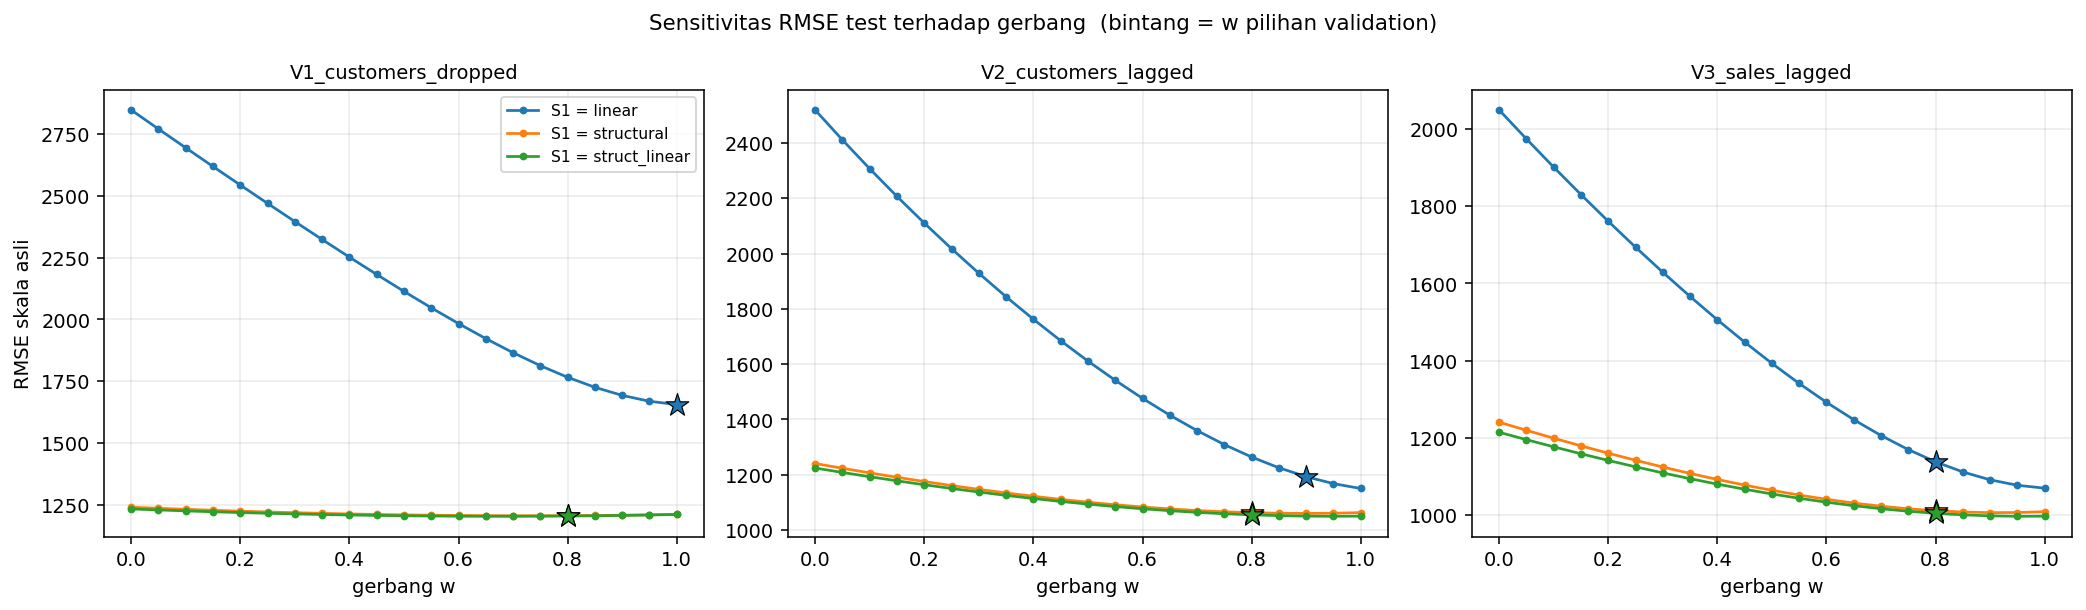

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), dpi=140, sharex=True)
for ax, variant in zip(axes, VARIANTS):
    for kind in A.STAGE1_KINDS:
        g = curve[(curve.varian == variant) & (curve.S1 == kind)]
        ax.plot(g.w, g["RMSE asli"], marker="o", ms=3, lw=1.4, label=f"S1 = {kind}")
        r = by_key[(variant, f"AR-LRX [{kind}]")]
        ws = r["gate_w"]
        ys = float(g.loc[np.isclose(g.w, ws), "RMSE asli"].iloc[0])
        ax.scatter([ws], [ys], s=150, marker="*", zorder=5, edgecolor="k", linewidth=.6)
    ax.set_title(variant, fontsize=10)
    ax.set_xlabel("gerbang w")
    ax.grid(alpha=.25)
axes[0].set_ylabel("RMSE skala asli")
axes[0].legend(fontsize=8)
fig.suptitle("Sensitivitas RMSE test terhadap gerbang  (bintang = w pilihan validation)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 6. Di mana AR-LRX menang atas XGBoost?

Pemecahan galat menurut segmen. Ini bukan sekadar pelengkap: ia menjelaskan
*mengapa* kerangka ini bekerja, dan itulah yang membedakan sumbangan metodologis
dari sekadar angka yang lebih kecil.

In [10]:
seg_rows = []
for variant in VARIANTS:
    d = datasets[variant]
    y = np.expm1(d.y_test)
    a = np.expm1(by_key[(variant, "AR-LRX [struct_linear]")]["_test_pred"])
    x = np.expm1(by_key[(variant, "XGBoost")]["_test_pred"])

    fn = list(d.feature_names)
    Xt = d.X_test
    promo = Xt[:, fn.index("Promo")] if "Promo" in fn else np.zeros(len(y))
    dow = Xt[:, fn.index("DayOfWeek")] if "DayOfWeek" in fn else np.zeros(len(y))

    def rmse(t, p, mask):
        return float(np.sqrt(np.mean((t[mask] - p[mask]) ** 2))) if mask.sum() else np.nan

    segments = {"semua": np.ones(len(y), bool),
                "promo": promo == 1, "tanpa promo": promo == 0}
    for dv in sorted(set(np.unique(dow).tolist()))[:7]:
        segments[f"hari {int(dv)}"] = dow == dv
    # desil volume toko berdasarkan rata-rata target di TEST hanya untuk pengelompokan
    # deskriptif (tidak dipakai untuk pemodelan apa pun)
    if "Store" in fn:
        st = Xt[:, fn.index("Store")]
        mean_by_store = pd.Series(y).groupby(pd.Series(st)).transform("mean").to_numpy()
        q = pd.Categorical(pd.qcut(mean_by_store, 4,
                                   labels=["Q1 kecil", "Q2", "Q3", "Q4 besar"],
                                   duplicates="drop"))
        for lab in q.categories:
            segments[f"toko {lab}"] = np.asarray(q == lab)

    for name, mask in segments.items():
        ra, rx = rmse(y, a, mask), rmse(y, x, mask)
        seg_rows.append({"varian": variant, "segmen": name, "n": int(mask.sum()),
                         "AR-LRX": ra, "XGBoost": rx,
                         "selisih (%)": (ra - rx) / rx * 100})

seg = pd.DataFrame(seg_rows)
seg.to_csv(f"../results/{EXPERIMENT}_segments.csv", index=False)
print("Negatif = AR-LRX lebih baik.")
for v in VARIANTS:
    print(f"\n--- {v} ---")
    display(seg[seg.varian == v].round(3).to_string(index=False))

Negatif = AR-LRX lebih baik.

--- V1_customers_dropped ---


'              varian        segmen      n   AR-LRX  XGBoost  selisih (%)\nV1_customers_dropped         semua 129333 1204.751 1651.251      -27.040\nV1_customers_dropped         promo  58399 1365.172 1848.483      -26.146\nV1_customers_dropped   tanpa promo  70934 1054.517 1469.133      -28.222\nV1_customers_dropped        hari 1  20121 1216.093 1784.424      -31.850\nV1_customers_dropped        hari 2  22284 1255.197 1682.141      -25.381\nV1_customers_dropped        hari 3  22281 1192.564 1598.009      -25.372\nV1_customers_dropped        hari 4  20516 1282.206 1643.033      -21.961\nV1_customers_dropped        hari 5  21205 1096.021 1511.469      -27.486\nV1_customers_dropped        hari 6  22286 1168.168 1684.654      -30.658\nV1_customers_dropped        hari 7    640 1555.953 1554.067        0.121\nV1_customers_dropped toko Q1 kecil  32421  781.680 1150.432      -32.053\nV1_customers_dropped       toko Q2  32275 1008.304 1205.109      -16.331\nV1_customers_dropped       toko Q3  3


--- V2_customers_lagged ---


'             varian        segmen      n   AR-LRX  XGBoost  selisih (%)\nV2_customers_lagged         semua 129333 1054.972 1111.439       -5.081\nV2_customers_lagged         promo  58399 1245.882 1285.364       -3.072\nV2_customers_lagged   tanpa promo  70934  866.795  944.510       -8.228\nV2_customers_lagged        hari 1  20121 1153.898 1313.907      -12.178\nV2_customers_lagged        hari 2  22284 1126.893 1110.729        1.455\nV2_customers_lagged        hari 3  22281 1102.096 1114.326       -1.098\nV2_customers_lagged        hari 4  20516 1118.706 1070.967        4.457\nV2_customers_lagged        hari 5  21205  911.912  982.584       -7.192\nV2_customers_lagged        hari 6  22286  889.500 1056.807      -15.831\nV2_customers_lagged        hari 7    640 1151.831 1234.734       -6.714\nV2_customers_lagged toko Q1 kecil  32421  708.401  710.162       -0.248\nV2_customers_lagged       toko Q2  32275  902.136  895.018        0.795\nV2_customers_lagged       toko Q3  32408 1049.319 


--- V3_sales_lagged ---


'         varian        segmen      n   AR-LRX  XGBoost  selisih (%)\nV3_sales_lagged         semua 129333 1004.695 1017.831       -1.291\nV3_sales_lagged         promo  58399 1172.707 1151.855        1.810\nV3_sales_lagged   tanpa promo  70934  841.564  892.512       -5.708\nV3_sales_lagged        hari 1  20121 1138.023 1273.462      -10.635\nV3_sales_lagged        hari 2  22284 1047.686  931.201       12.509\nV3_sales_lagged        hari 3  22281 1017.817  974.122        4.486\nV3_sales_lagged        hari 4  20516 1047.709  921.341       13.716\nV3_sales_lagged        hari 5  21205  885.864  905.664       -2.186\nV3_sales_lagged        hari 6  22286  870.778 1060.175      -17.865\nV3_sales_lagged        hari 7    640 1179.347 1270.410       -7.168\nV3_sales_lagged toko Q1 kecil  32421  694.062  657.076        5.629\nV3_sales_lagged       toko Q2  32275  875.476  837.003        4.596\nV3_sales_lagged       toko Q3  32408  986.255  991.031       -0.482\nV3_sales_lagged toko Q4 besar  32

## 7. Ringkasan untuk naskah

Sel di bawah mencetak kalimat-kalimat yang dapat langsung dipakai, dengan angka
yang terisi dari hasil sebenarnya - supaya tidak ada angka yang disalin tangan.

In [11]:
print("="*88)
for variant in VARIANTS:
    sub = results[results.feature_set == variant].set_index("model")
    b = sub.loc["AR-LRX [struct_linear]"]
    nv = sub.loc["SeasonalNaive(store x dow x promo median)", "orig_RMSE"]
    xg = sub.loc["XGBoost", "orig_RMSE"]
    ol = sub.loc["LR-XGB (residual, tanpa gerbang)", "orig_RMSE"]
    s1 = sub.loc["S1 [struct_linear]", "orig_RMSE"]
    dsub = dm2[(dm2.varian == variant) & (dm2.S1 == "struct_linear")].set_index("pembanding")
    print(f"\n{variant}")
    print(f"  AR-LRX [struct_linear], w* = {b.gate_w}, RMSE = {b.orig_RMSE:.2f} "
          f"(MAE {b.orig_MAE:.2f}, RMSPE {b.orig_RMSPE:.5f}, R2 {b.orig_R2:.4f})")
    for lab, ref, key in [("naif per toko", nv, "Naif per toko"),
                          ("XGBoost polos", xg, "XGBoost polos"),
                          ("kerangka lama", ol, "Kerangka lama"),
                          ("tahap pertama sendirian", s1, "S1 [struct_linear] sendirian")]:
        d_ = (b.orig_RMSE - ref) / ref * 100
        p_ = dsub.loc[key, "p (asli)"]
        print(f"    lebih baik {abs(d_):5.2f}% dari {lab:24s} (DM skala asli, p = {p_:.3g})")
print("\n" + "="*88)
print(f"Kedua skala DM sepakat pada {int(dm2.sepakat.sum())}/{len(dm2)} perbandingan.")
print(f"Harga memilih w dari validation, bukan test: rata-rata "
      f"{gap['harga kesalahan pilih (%)'].mean():.4f}%, maksimum "
      f"{gap['harga kesalahan pilih (%)'].max():.4f}%.")
print("Berkas yang dihasilkan:")
for f in sorted(os.listdir("../results")):
    if f.startswith(EXPERIMENT):
        print(f"  ../results/{f}")


V1_customers_dropped
  AR-LRX [struct_linear], w* = 0.8, RMSE = 1204.75 (MAE 815.30, RMSPE 0.14746, R2 0.8513)
    lebih baik  5.48% dari naif per toko            (DM skala asli, p = 0)
    lebih baik 27.04% dari XGBoost polos            (DM skala asli, p = 0)
    lebih baik 27.23% dari kerangka lama            (DM skala asli, p = 0)
    lebih baik  2.33% dari tahap pertama sendirian  (DM skala asli, p = 0)

V2_customers_lagged
  AR-LRX [struct_linear], w* = 0.8, RMSE = 1054.97 (MAE 720.69, RMSPE 0.13006, R2 0.8860)
    lebih baik 17.23% dari naif per toko            (DM skala asli, p = 0)
    lebih baik  5.08% dari XGBoost polos            (DM skala asli, p = 0)
    lebih baik  8.29% dari kerangka lama            (DM skala asli, p = 0)
    lebih baik 13.84% dari tahap pertama sendirian  (DM skala asli, p = 0)

V3_sales_lagged
  AR-LRX [struct_linear], w* = 0.8, RMSE = 1004.69 (MAE 690.89, RMSPE 0.12726, R2 0.8966)
    lebih baik 21.18% dari naif per toko            (DM skala asli, p 